In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

sample_funds = nav_history["amfi_code"].unique()[:10]

plot_df = nav_history[
    nav_history["amfi_code"].isin(sample_funds)
]

fig = px.line(
    plot_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trends (2022-2026)"
)

fig.show()

In [7]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

print(aum[["date", "year"]].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


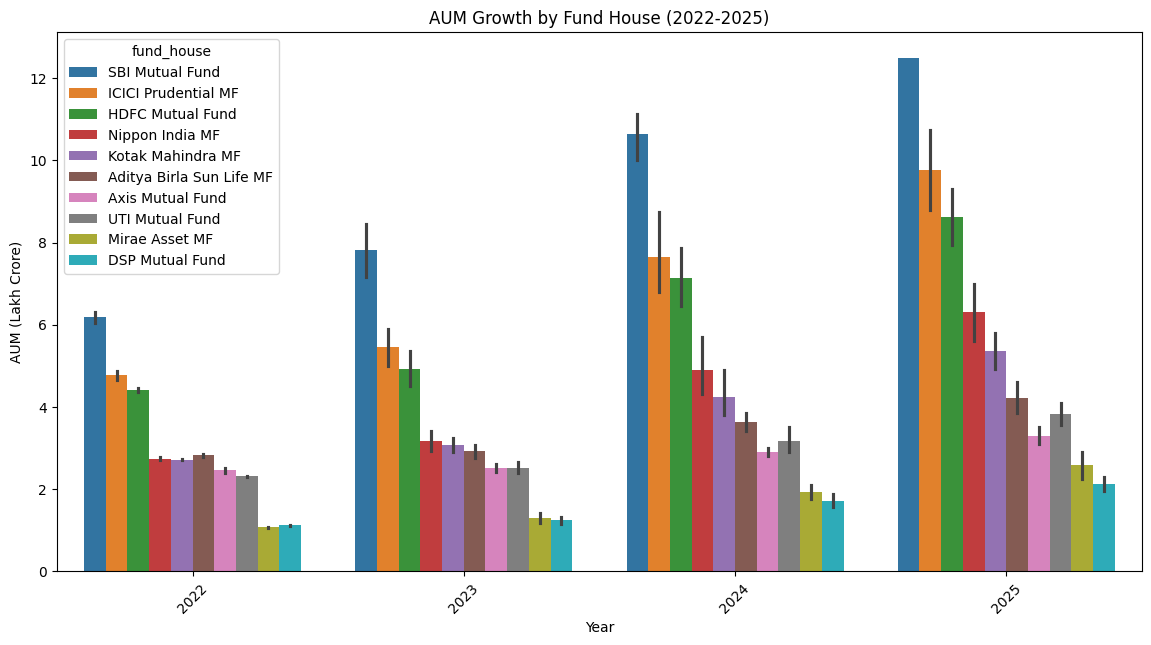

In [8]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.show()

Insight 1:
SBI Mutual Fund maintains one of the highest AUM levels among fund houses, indicating strong investor trust and market presence.

In [14]:
sip.head()
print(sip.columns.tolist())
sip["month"] = pd.to_datetime(sip["month"])

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [15]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

fig.show()

In [19]:
max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [20]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
    markers=True
)

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="All-Time High ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

Insight 2:
Monthly SIP inflows increased consistently from 2022 to 2025, reaching an all-time high of ₹31,002 Cr in December 2025, reflecting strong retail investor participation in mutual funds.

In [21]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


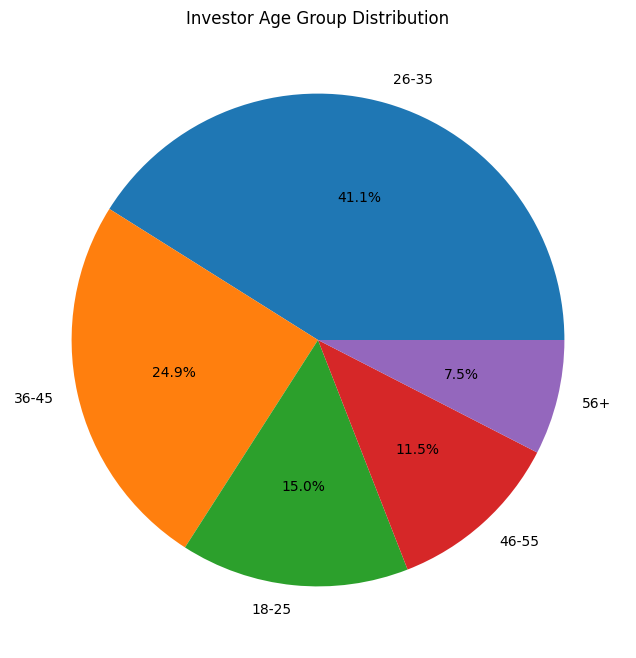

In [22]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

Insight 3:
The 26–35 age group forms the largest investor segment with 13,463 investors, indicating strong mutual fund adoption among young professionals.

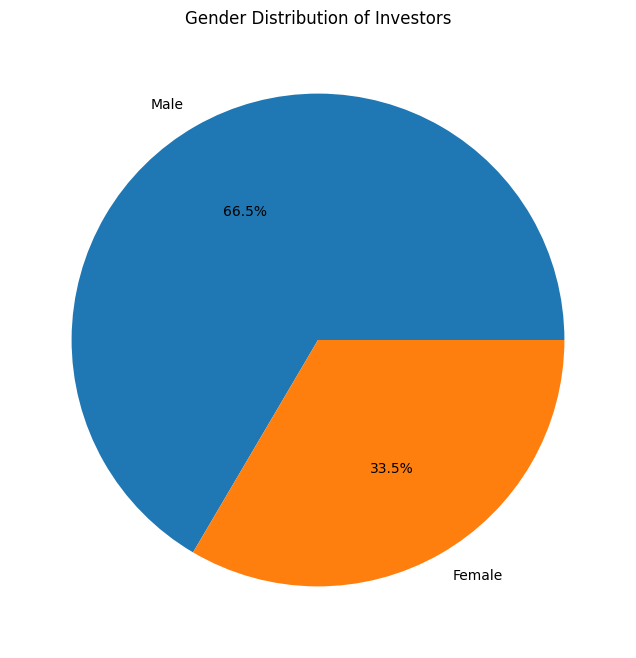

In [23]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.show()

Insight 4:
Investors aged 26–45 account for the majority of mutual fund participation, highlighting the importance of the mid-career demographic.

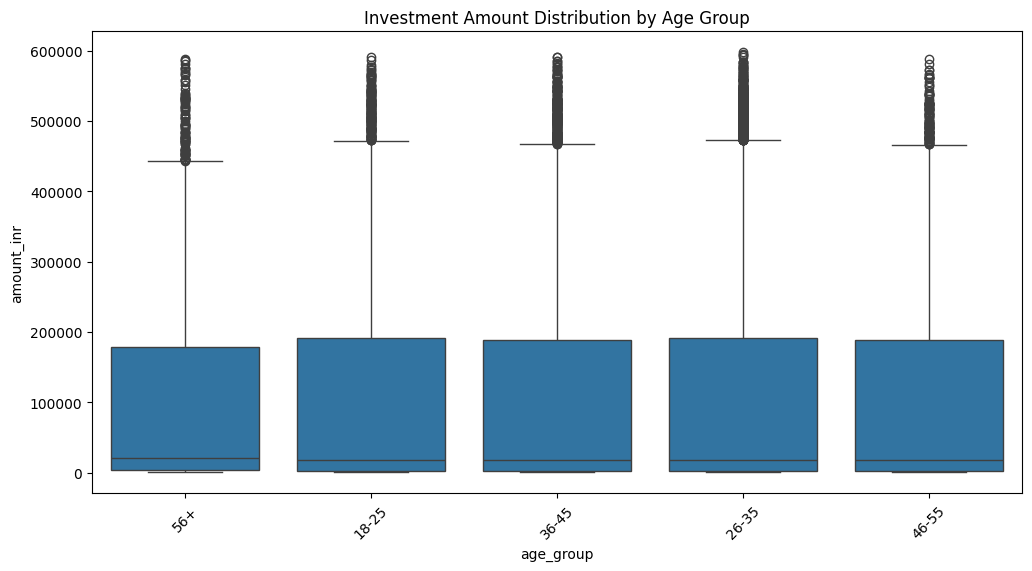

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.xticks(rotation=45)

plt.show()

Insight 5:
Male investors account for 21,809 of the 32,778 investors (~66.5%), while female investors account for 10,969 (~33.5%). This indicates a significant gender gap in mutual fund participation.

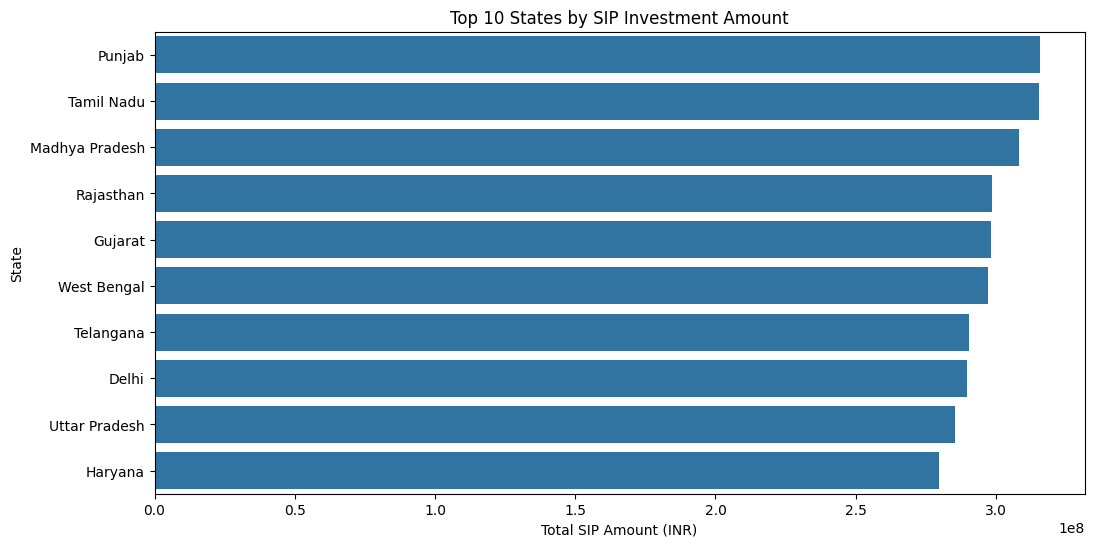

In [25]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Top 10 States by SIP Investment Amount")

plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

Insight 6:
Although male investors dominate the investor base, female participation represents one-third of all investors, highlighting a growing opportunity for targeted financial inclusion and investment awareness programs.

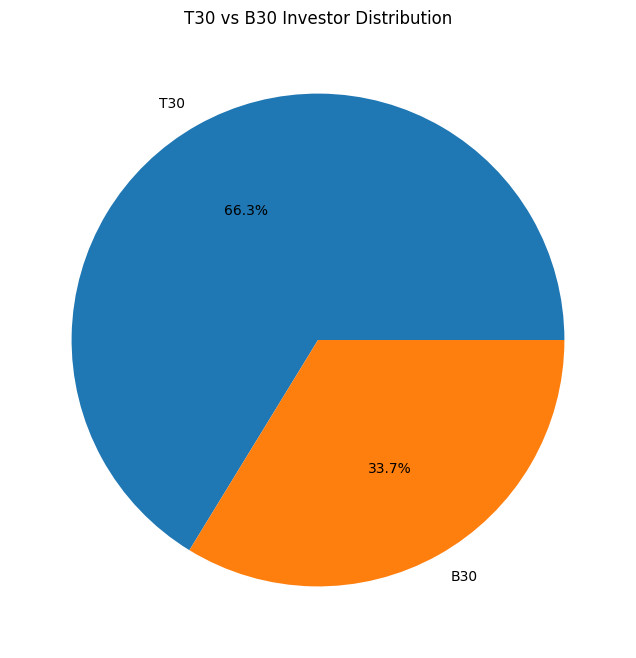

In [26]:
tier_counts = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

Insight 7:
Punjab recorded the highest total investment amount at ₹315.8 million, closely followed by Tamil Nadu and Madhya Pradesh. Investment activity is distributed across multiple states rather than being concentrated in a single region.

In [27]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

In [28]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

print(transactions.shape)

(32778, 13)


In [3]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print(state_amount.head(10))

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64


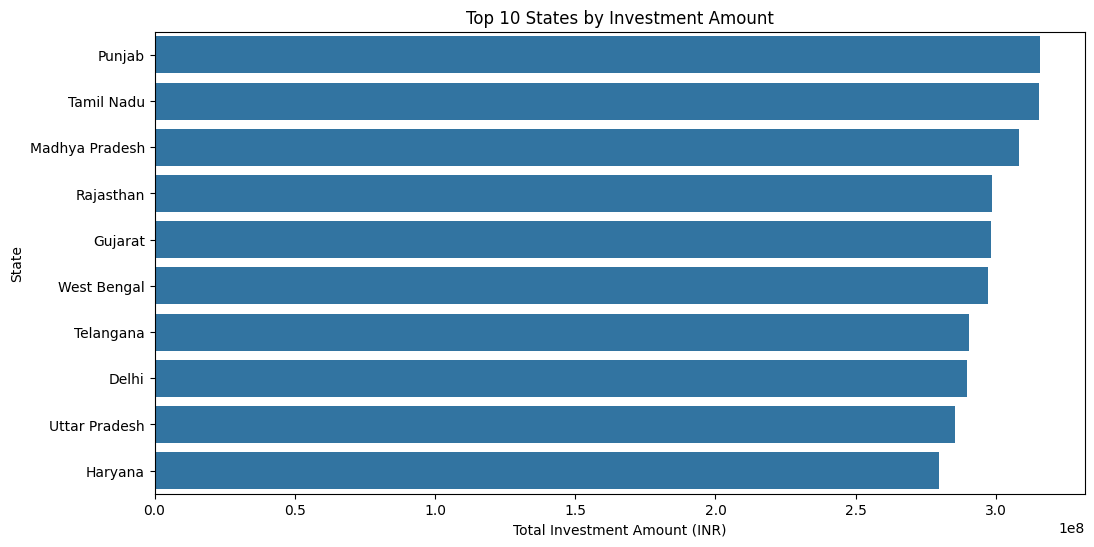

In [4]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_amount.head(10).values,
    y=state_amount.head(10).index
)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.show()

Insight 8:
The difference between the highest and tenth-ranked state is relatively small, indicating broad geographic participation in mutual fund investments across India.

In [5]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

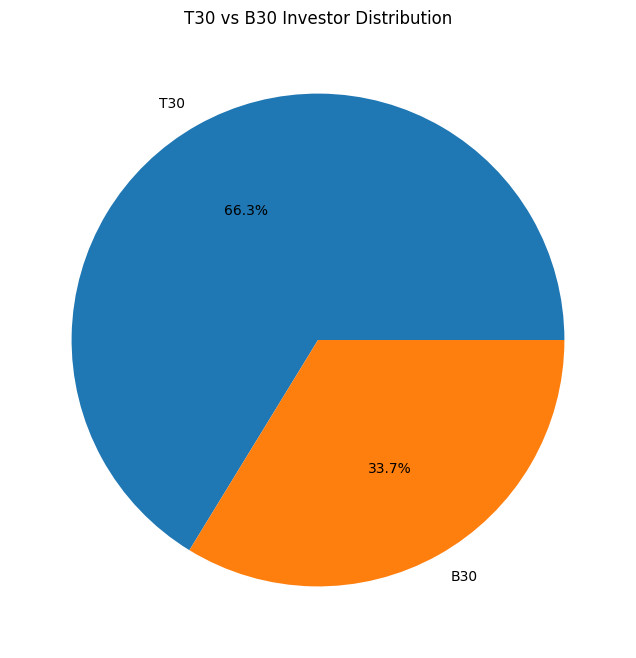

In [6]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

Insight 9:
T30 cities account for 21,719 investors (66.3%), while B30 cities contribute 11,059 investors (33.7%). Although metropolitan cities dominate mutual fund participation, one-third of investors originate from emerging B30 markets.

Insight 10:
The strong participation from B30 cities indicates increasing financial awareness and mutual fund adoption beyond major metropolitan regions.

In [8]:
import pandas as pd

category = pd.read_csv(
    "../data/processed/05_category_inflows.csv"
)

print(category.shape)

(144, 3)


In [9]:
print(category.head())
print(category.columns.tolist())

        month         category  net_inflow_crore
0  2024-04-01        Large Cap            2413.0
1  2024-04-01          Mid Cap            3897.0
2  2024-04-01        Small Cap            3533.0
3  2024-04-01        Flexi Cap            4947.0
4  2024-04-01  Large & Mid Cap            4214.0
['month', 'category', 'net_inflow_crore']


In [10]:
category["month"] = pd.to_datetime(
    category["month"]
)

In [11]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

print(heatmap_data.head())

month            2024-04-01  2024-05-01  2024-06-01  2024-07-01  2024-08-01  \
category                                                                      
ELSS                  466.0       553.0       472.0       471.0       499.0   
Flexi Cap            4947.0      5529.0      4478.0      4869.0      5562.0   
Gilt                  784.0       836.0       864.0       959.0       952.0   
Hybrid               2955.0      3487.0      3163.0      3291.0      3684.0   
Large & Mid Cap      4214.0      4368.0      4610.0      5023.0      5411.0   

month            2024-09-01  2024-10-01  2024-11-01  2024-12-01  2025-01-01  \
category                                                                      
ELSS                  537.0       537.0       571.0       521.0       516.0   
Flexi Cap            5397.0      6004.0      6111.0      4654.0      5603.0   
Gilt                  925.0       898.0       704.0       831.0       744.0   
Hybrid               3015.0      3314.0      3264.0

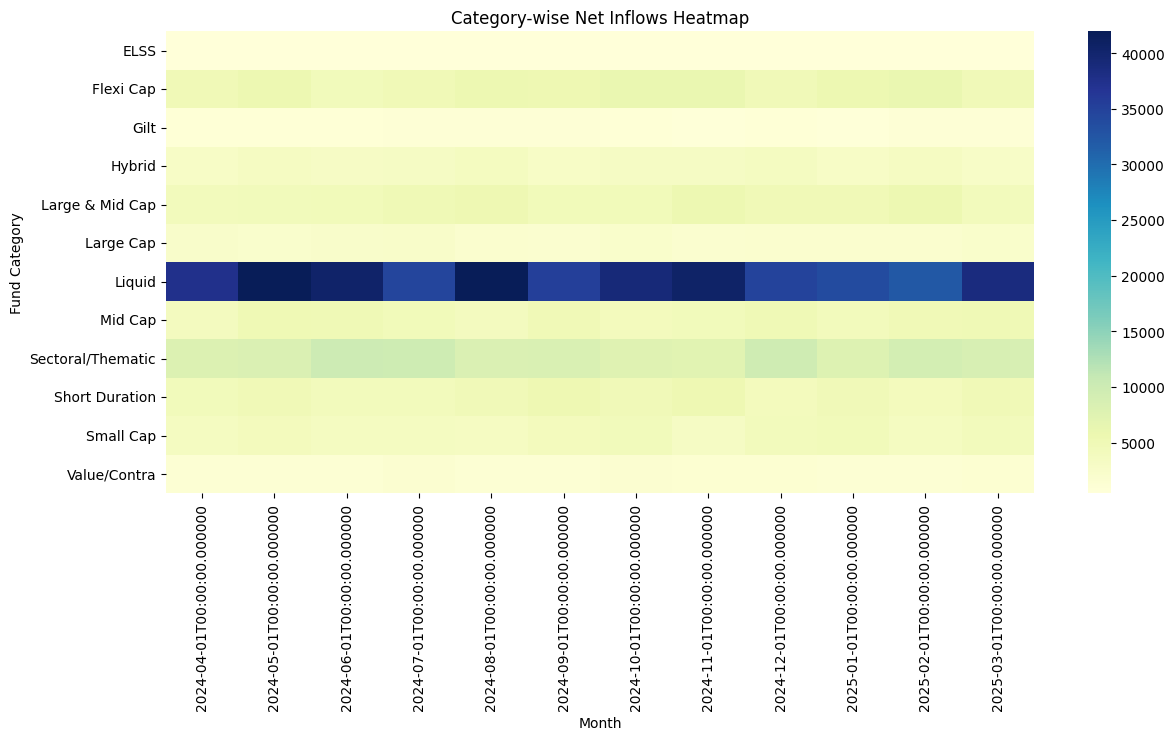

In [12]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

Insight 11:
Equity-oriented categories such as Large Cap, Mid Cap, Small Cap, and Flexi Cap consistently attracted positive inflows, indicating sustained investor preference for equity mutual funds.

In [13]:
folio = pd.read_csv(
    "../data/processed/06_industry_folio_count.csv"
)

print(folio.head())
print(folio.columns.tolist())

        month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01-01               13.26                 9.28               1.86   
1  2022-04-01               13.91                 9.74               1.95   
2  2022-07-01               13.85                 9.69               1.94   
3  2022-10-01               14.12                 9.88               1.98   
4  2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


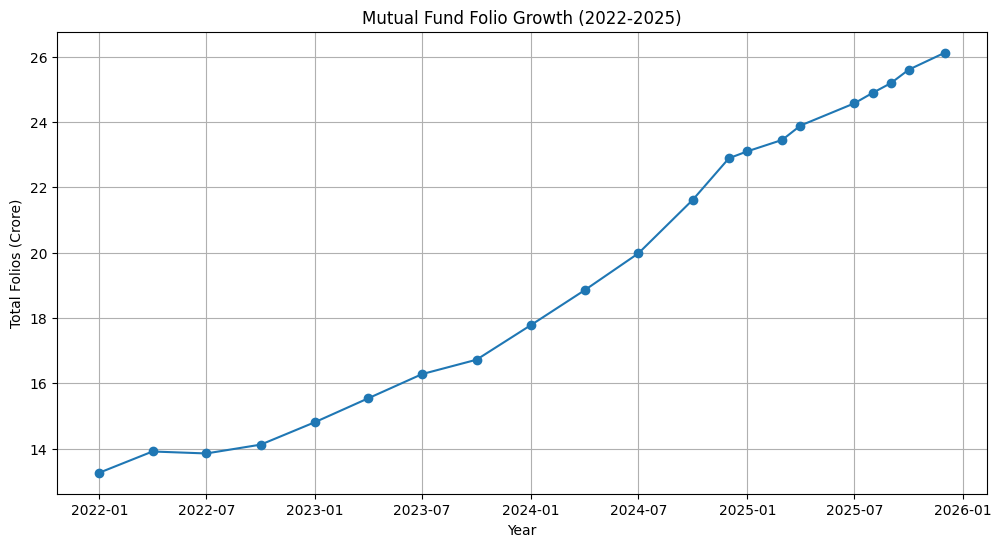

In [14]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

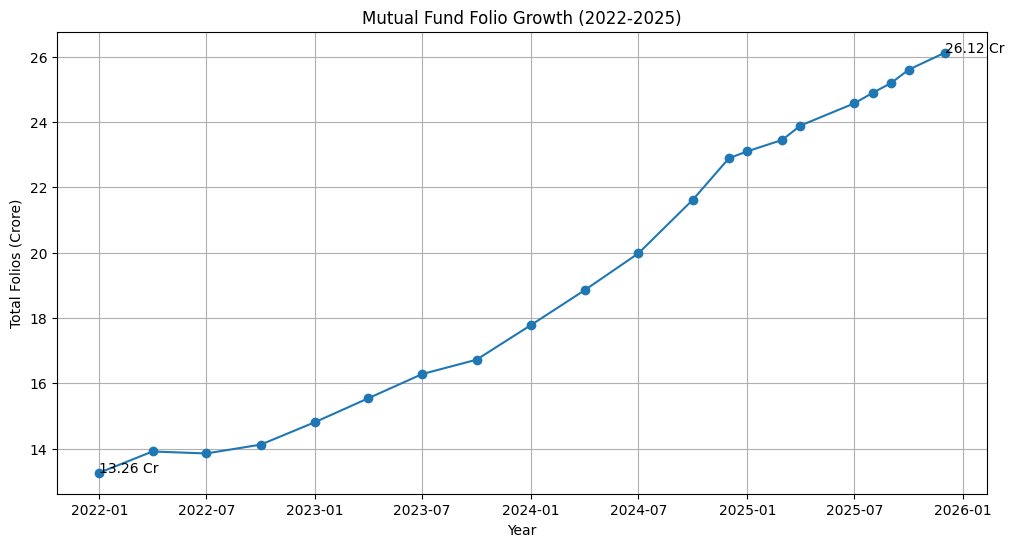

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    xy=(folio.iloc[0]["month"],
        folio.iloc[0]["total_folios_crore"])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio.iloc[-1]["month"],
        folio.iloc[-1]["total_folios_crore"])
)

plt.title("Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

Insight 11:
Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting a near doubling of investor accounts over four years.

Insight 12:
The steady rise in folio counts indicates sustained retail investor participation and growing adoption of mutual fund investments across India.

In [18]:
fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

In [19]:
print(nav_history.head())
print(nav_history.columns.tolist())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
['amfi_code', 'date', 'nav']


In [20]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

In [21]:
selected_funds = (
    nav_history["amfi_code"]
    .unique()[:10]
)

nav_subset = nav_history[
    nav_history["amfi_code"]
    .isin(selected_funds)
]

pivot_nav = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

print(pivot_nav.head())

amfi_code     100016   100025    100033    101206   101207    101208   102885  \
date                                                                            
2022-01-03  520.4608  26.3169  107.3758  305.0996  38.5736  310.7415  89.8728   
2022-01-04  515.0971  26.2234  105.9447  305.4514  38.1545  310.6977  90.8724   
2022-01-05  521.7239  26.2221  105.4800  306.6324  38.1775  310.8165  90.1565   
2022-01-06  515.7880  26.1728  104.9350  305.9800  37.0665  310.7719  91.5338   
2022-01-07  515.1639  26.2261  104.3318  304.0480  37.9845  310.8388  90.6762   

amfi_code     102886    102887   118632  
date                                     
2022-01-03  119.2905  191.0721  42.8339  
2022-01-04  120.6402  189.0737  42.8033  
2022-01-05  121.4580  188.0701  43.0564  
2022-01-06  125.2386  190.4545  43.2088  
2022-01-07  124.1321  187.3124  42.9585  


In [22]:
returns = pivot_nav.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [23]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


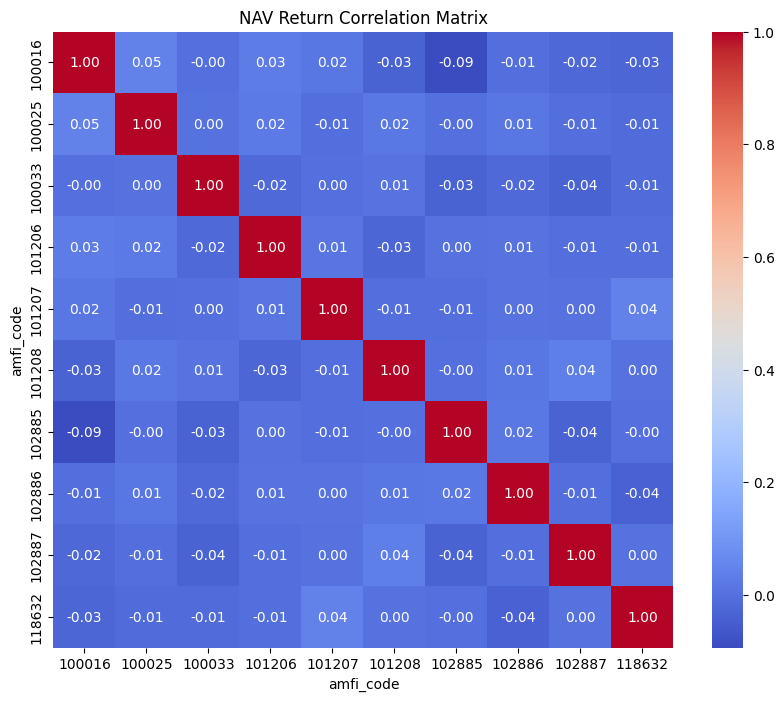

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

Insight 13:
Most selected mutual funds exhibit positive return correlations, indicating that broad market movements influence fund performance.

Insight 14:
Funds with lower correlation values may provide better diversification opportunities for investors seeking risk reduction.

In [25]:
portfolio = pd.read_csv(
    "../data/processed/09_portfolio_holdings.csv"
)

print(portfolio.head())
print(portfolio.columns.tolist())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [26]:
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

print(sector_data)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


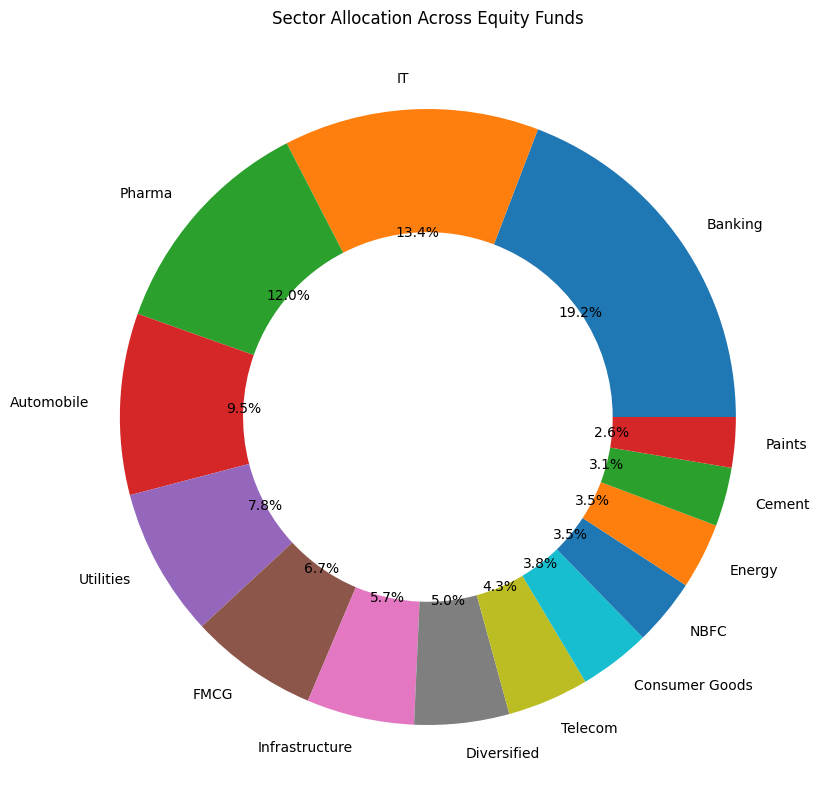

In [27]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width": 0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

Insight 15:
Banking, Utilities, Pharma, and Diversified sectors constitute a significant portion of mutual fund portfolios, indicating a preference for established and defensive sectors.

In [ ]:
plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [29]:
plt.savefig(
    "../reports/sip_trend.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [30]:
plt.savefig(
    "../reports/age_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [31]:
plt.savefig(
    "../reports/gender_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [32]:
plt.savefig(
    "../reports/state_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig(
    "../reports/city_tier_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig(
    "../reports/category_heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [35]:
plt.savefig(
    "../reports/folio_growth.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig(
    "../reports/correlation_matrix.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [37]:
plt.savefig(
    "../reports/sector_allocation.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

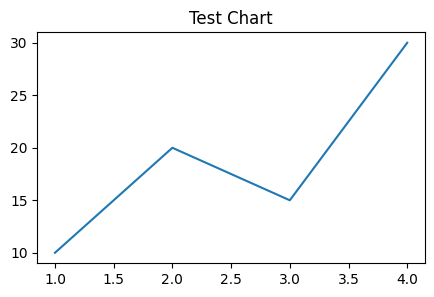

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))

plt.plot([1, 2, 3, 4], [10, 20, 15, 30])

plt.title("Test Chart")

plt.savefig("../reports/test_chart.png")

plt.show()

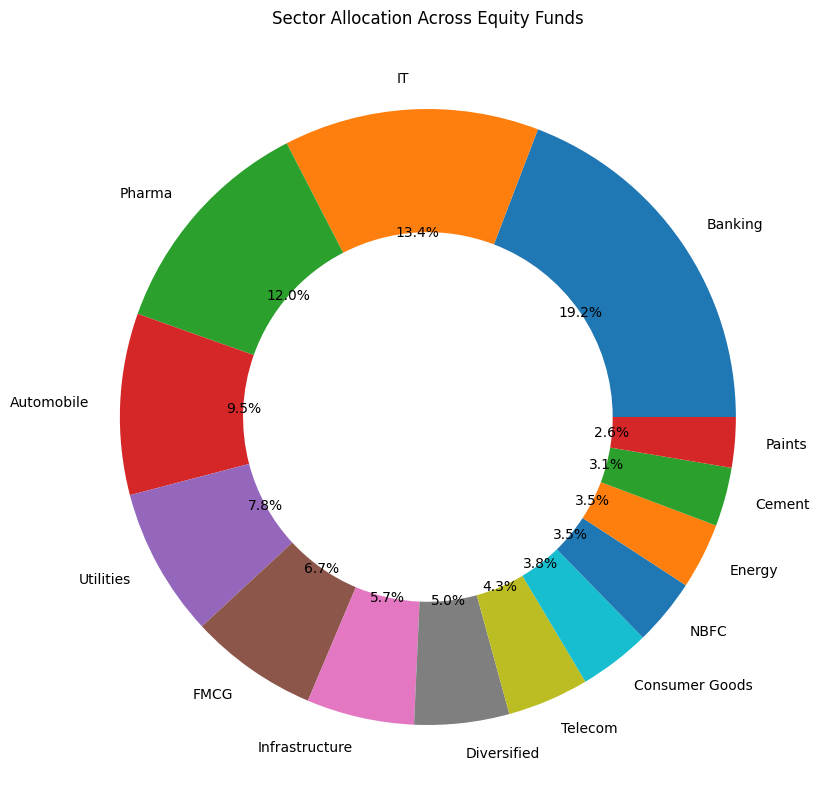

In [39]:
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width": 0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

Insight:
Banking and other core sectors represent a significant share of mutual fund portfolios, reflecting a preference for established industries.

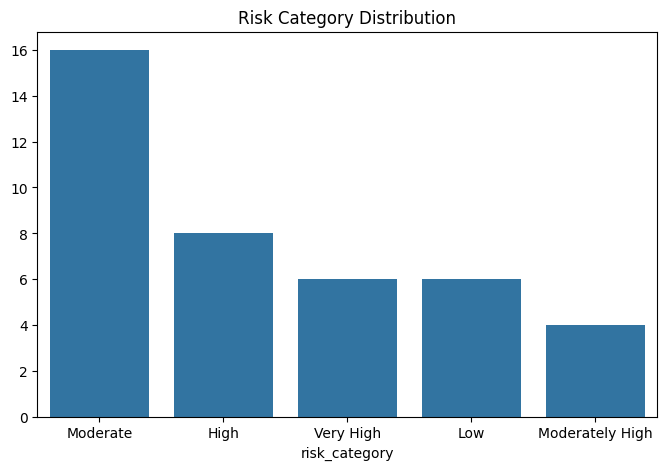

In [40]:
risk_counts = fund_master["risk_category"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=risk_counts.index, y=risk_counts.values)
plt.title("Risk Category Distribution")
plt.show()

Insight 16:
The majority of mutual fund schemes fall under High and Very High risk categories, reflecting the industry's strong focus on equity-oriented investment products.

Insight 17:
Low-risk debt-oriented schemes represent a smaller share of the total scheme universe, indicating greater product diversity in growth-focused categories.

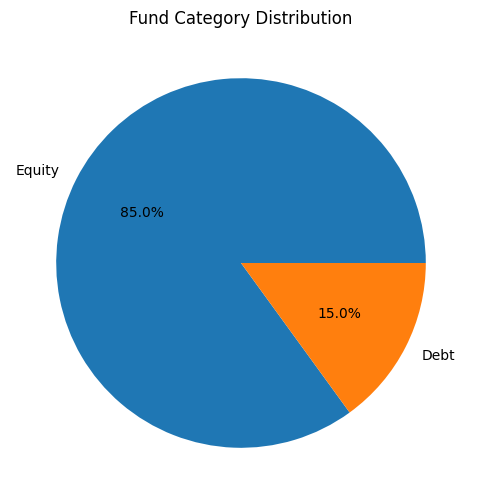

In [41]:
category_counts = fund_master["category"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(category_counts, labels=category_counts.index, autopct="%1.1f%%")
plt.title("Fund Category Distribution")
plt.show()

Insight 18:
Equity funds constitute the dominant share of schemes in the dataset, highlighting investor preference for long-term wealth creation through equity markets.

Insight 19;
Debt funds continue to play an important role by offering lower-risk investment alternatives for conservative investors.

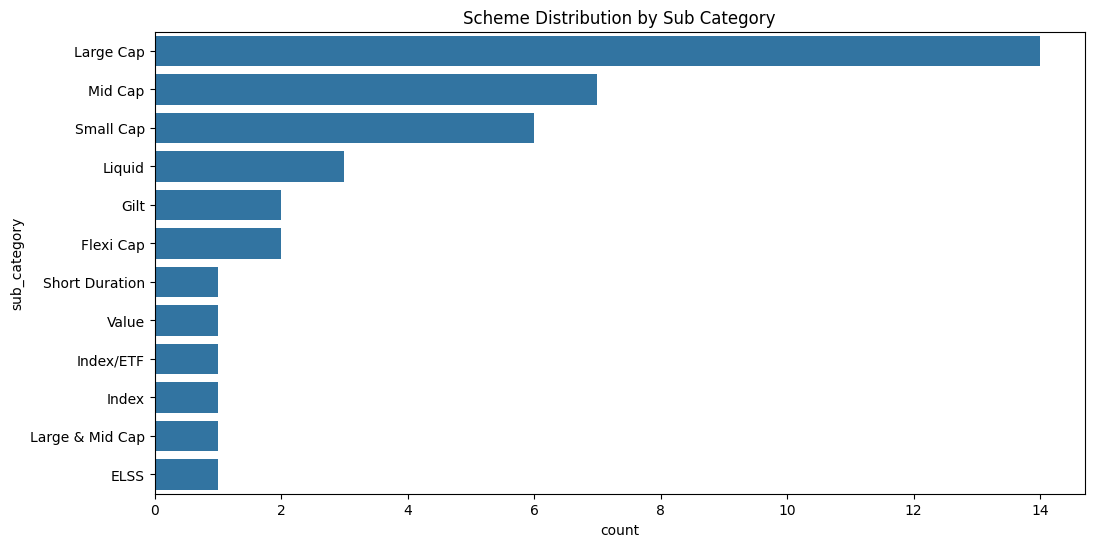

In [42]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=fund_master,
    y="sub_category",
    order=fund_master["sub_category"].value_counts().index
)

plt.title("Scheme Distribution by Sub Category")
plt.show()

Insight 20:
Large Cap, Flexi Cap, and Mid Cap categories contain a significant number of schemes, demonstrating strong demand for diversified equity investment options.

Insight 21:
Specialized categories such as ELSS and Gilt funds represent niche segments catering to tax-saving and fixed-income investment objectives.

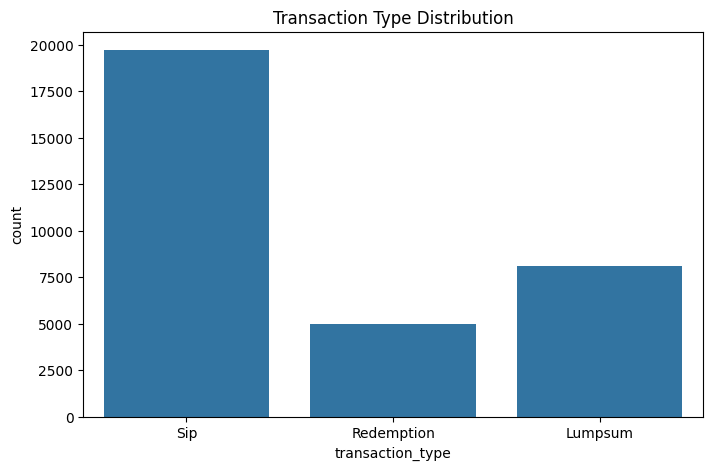

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="transaction_type"
)

plt.title("Transaction Type Distribution")
plt.show()

Insight 22:
SIP transactions account for a substantial portion of investor activity, indicating growing adoption of disciplined and systematic investing.

Insight 23:
The presence of redemption transactions highlights active portfolio management and liquidity requirements among investors.

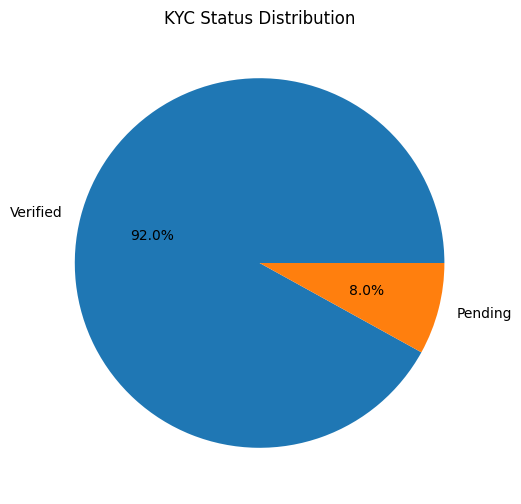

In [44]:
plt.figure(figsize=(6,6))

kyc_counts = transactions["kyc_status"].value_counts()

plt.pie(
    kyc_counts,
    labels=kyc_counts.index,
    autopct="%1.1f%%"
)

plt.title("KYC Status Distribution")
plt.show()

Insight 24:
The relatively small share of pending KYC cases suggests efficient onboarding and verification processes across investment platforms.

Insight 25:
A large majority of investors have completed KYC verification, demonstrating strong regulatory compliance within the mutual fund ecosystem.

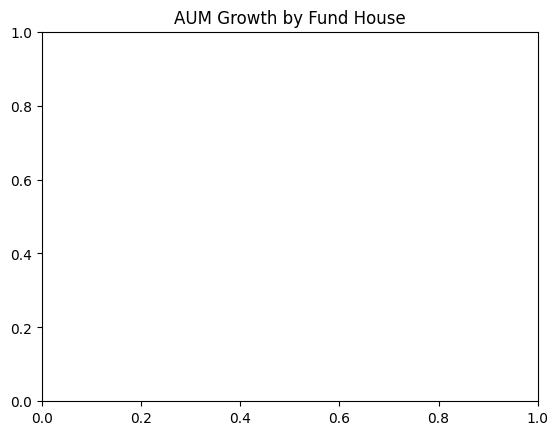

In [45]:
plt.title("AUM Growth by Fund House")

plt.savefig(
    "../reports/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
print(aum.head())

print(aum.columns)

print(aum.dtypes)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object


In [48]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [49]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

print(aum[["date", "year"]].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


In [50]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='str')


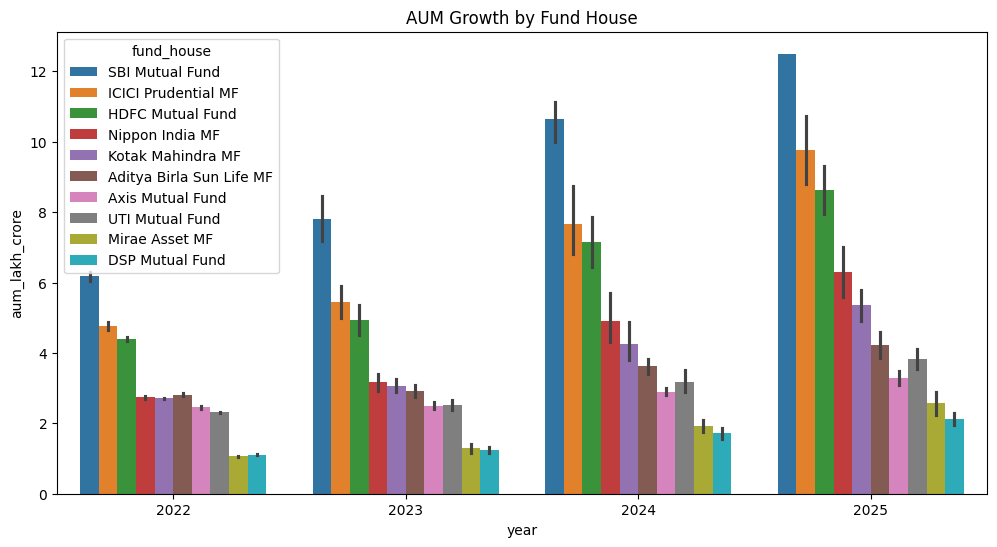

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.show()

In [52]:
plt.savefig(
    "../reports/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

Figure(1200x600)


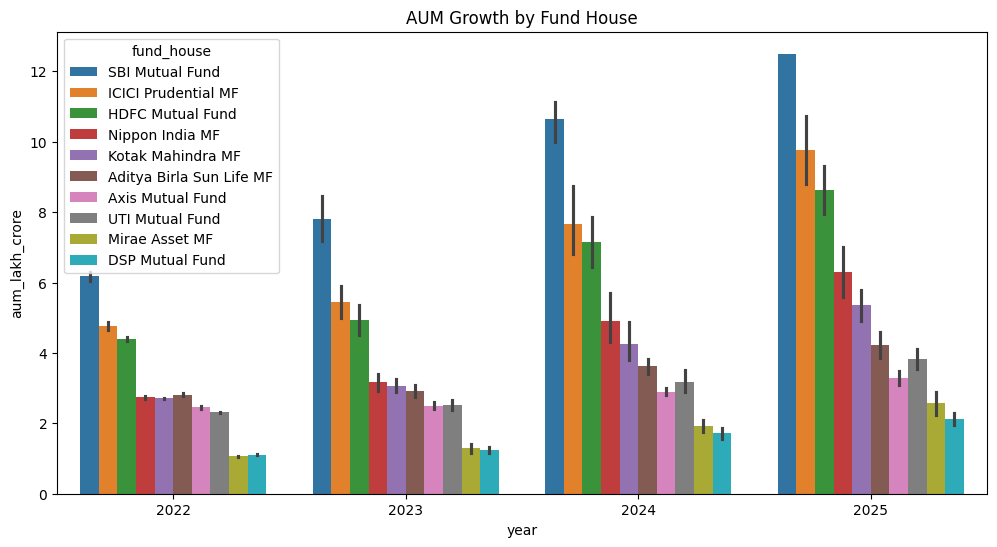

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

# Save BEFORE show
plt.savefig(
    "../reports/aum_growth_test.png",
    dpi=300,
    bbox_inches="tight"
)

# Verify figure still exists
print(plt.gcf())

plt.show()

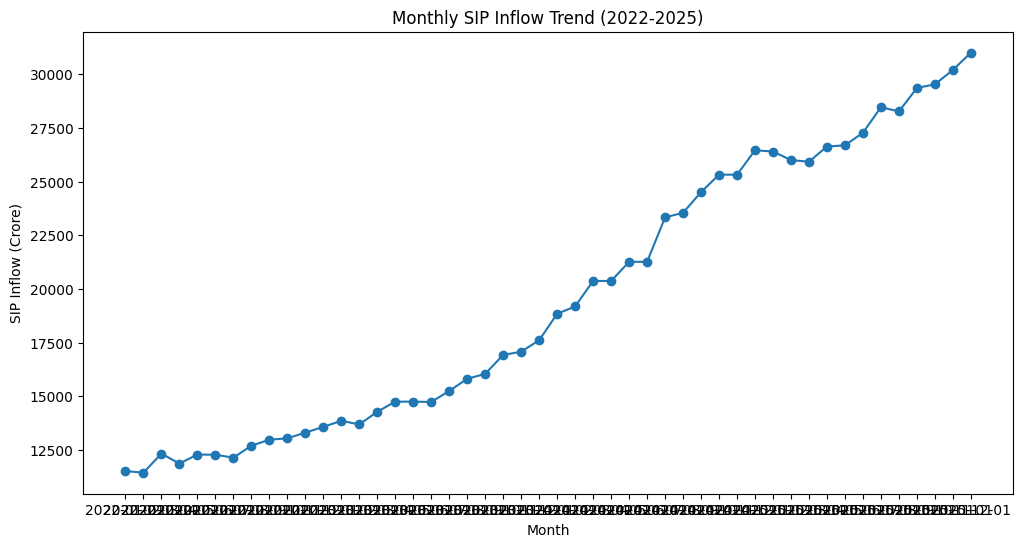

In [54]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.savefig(
    "../reports/sip_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

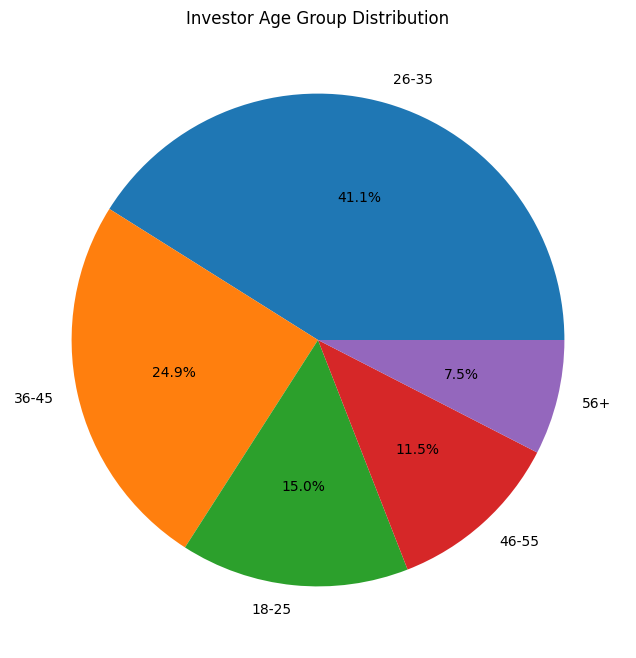

In [55]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

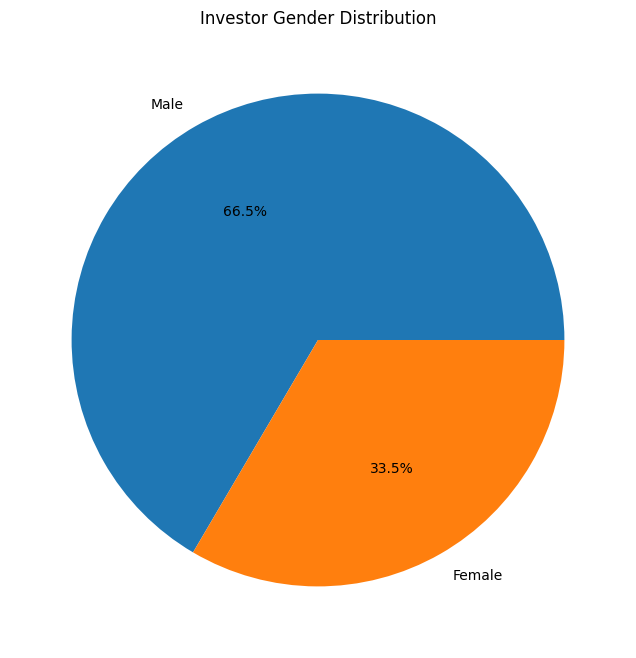

In [56]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

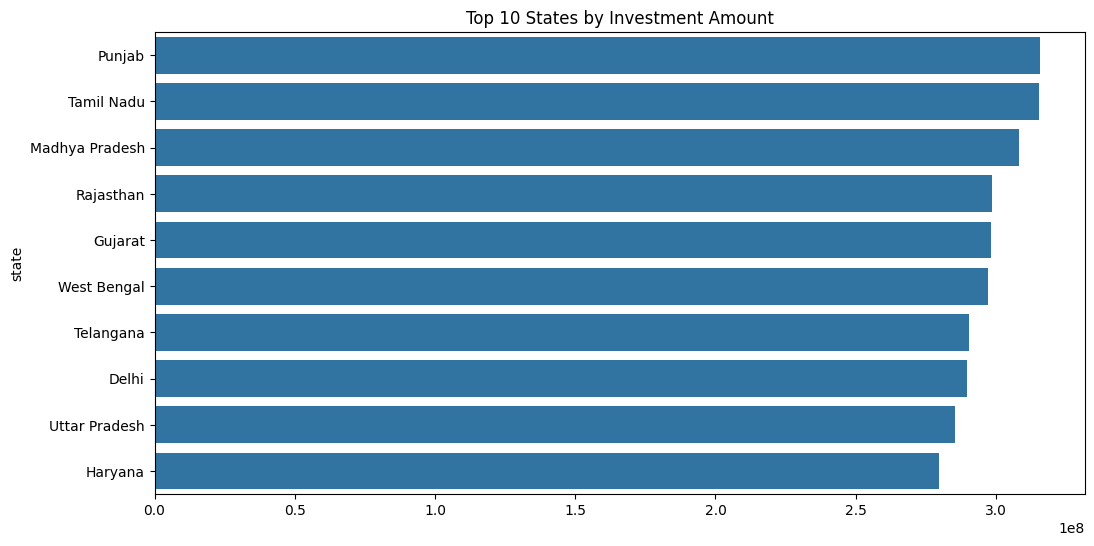

In [57]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_amount.head(10).values,
    y=state_amount.head(10).index
)

plt.title("Top 10 States by Investment Amount")

plt.savefig(
    "../reports/state_investment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

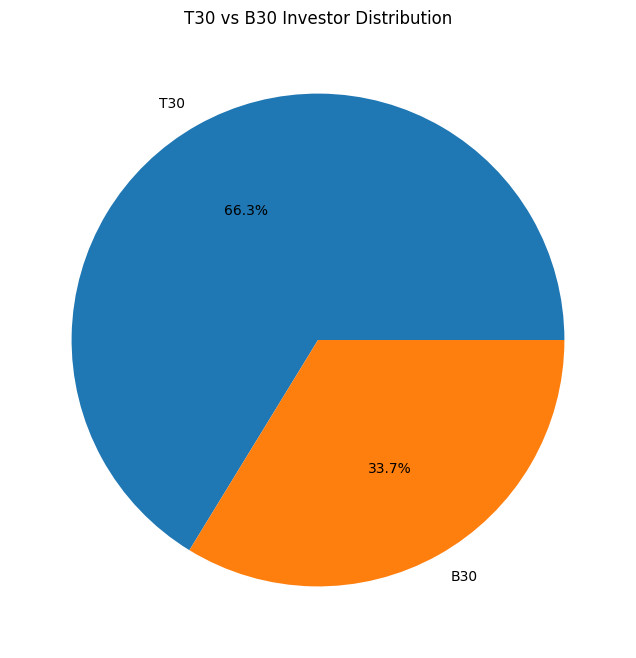

In [58]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

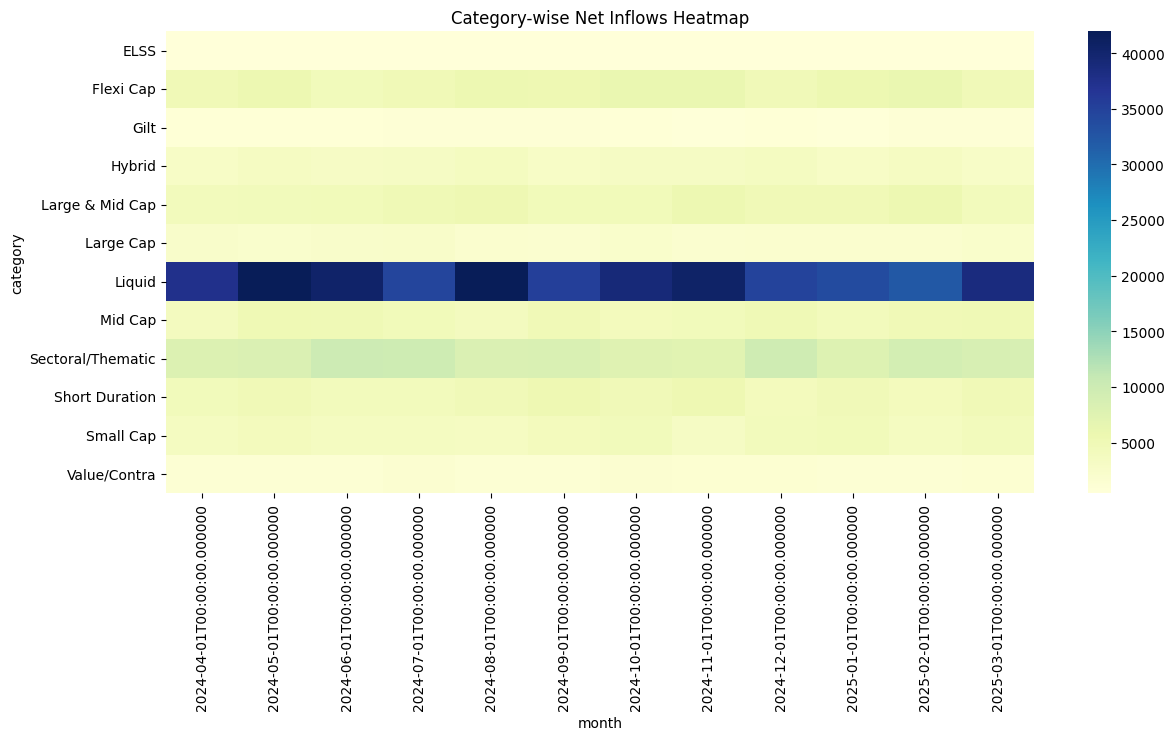

In [59]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")

plt.savefig(
    "../reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

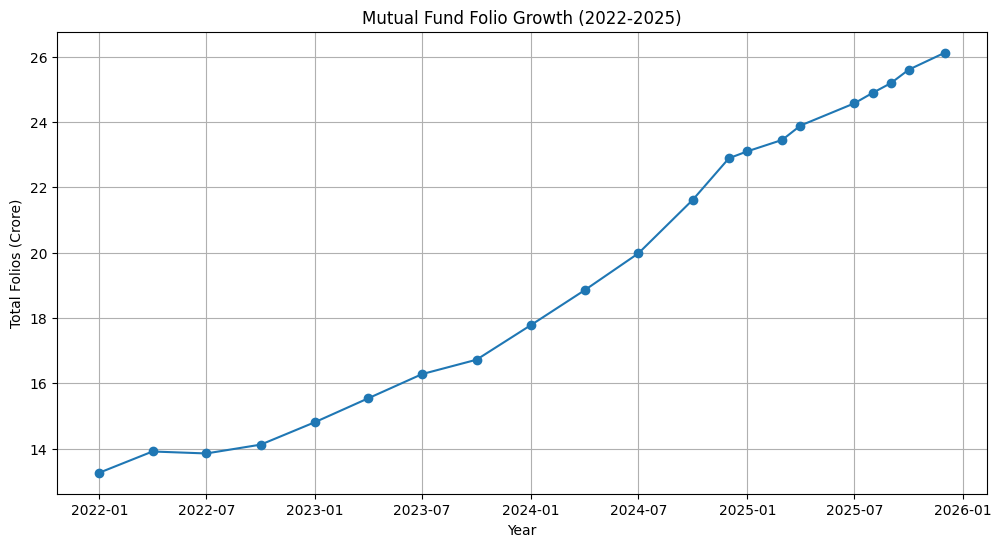

In [60]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.savefig(
    "../reports/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

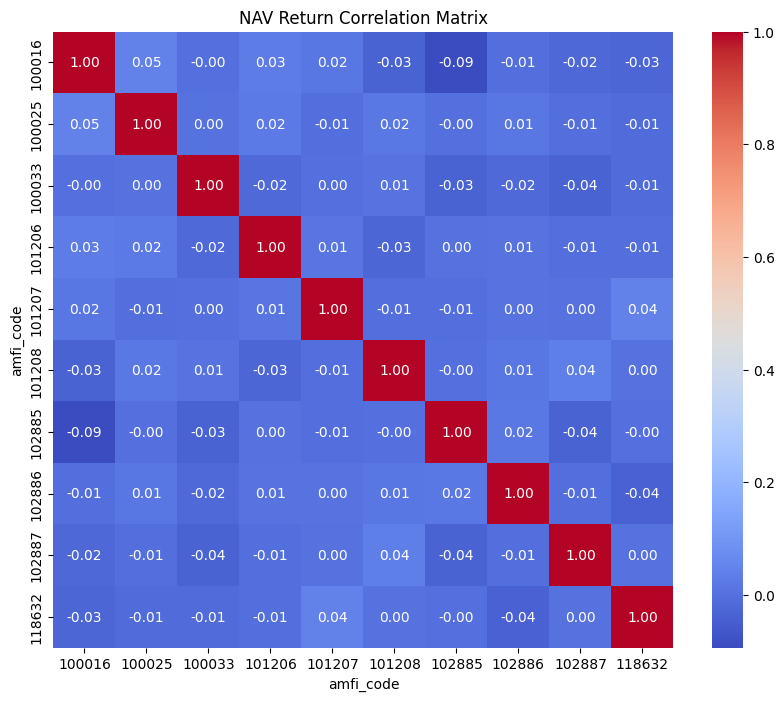

In [61]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "../reports/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

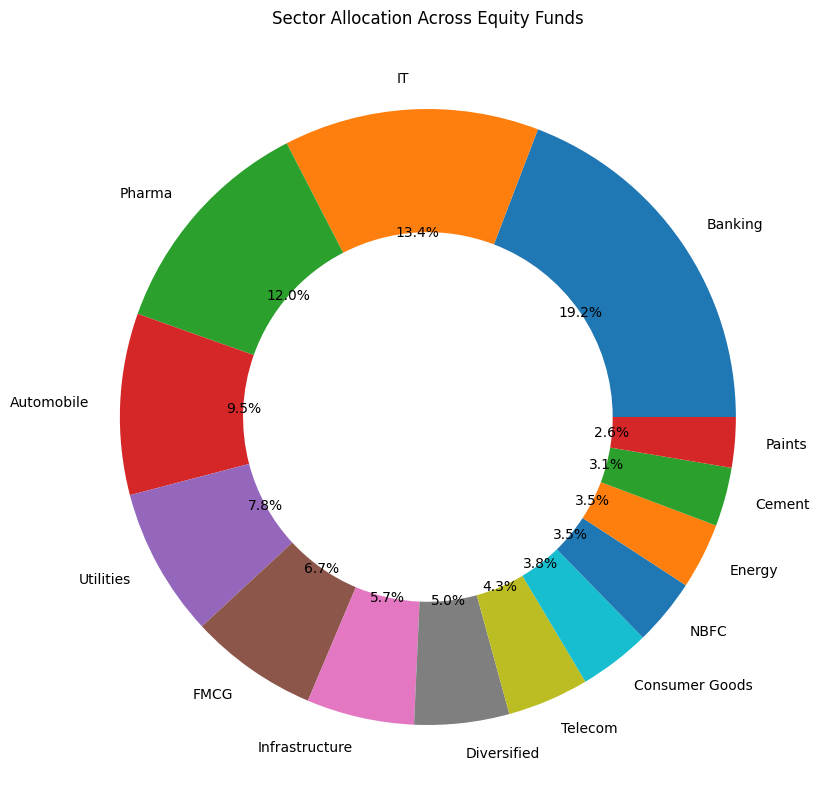

In [62]:
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../reports/sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

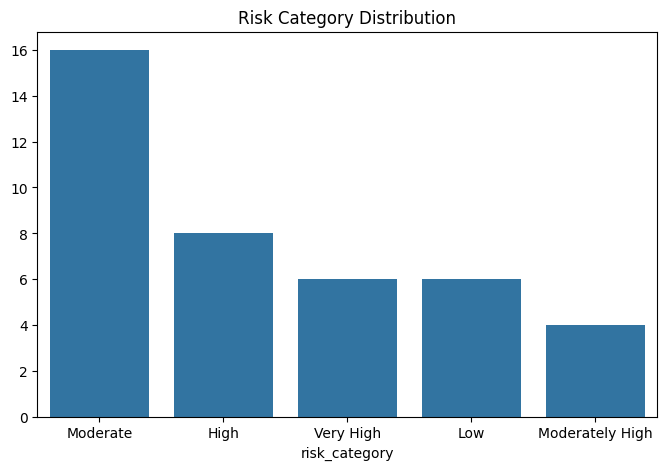

In [63]:
risk_counts = fund_master["risk_category"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Risk Category Distribution")

plt.savefig(
    "../reports/risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

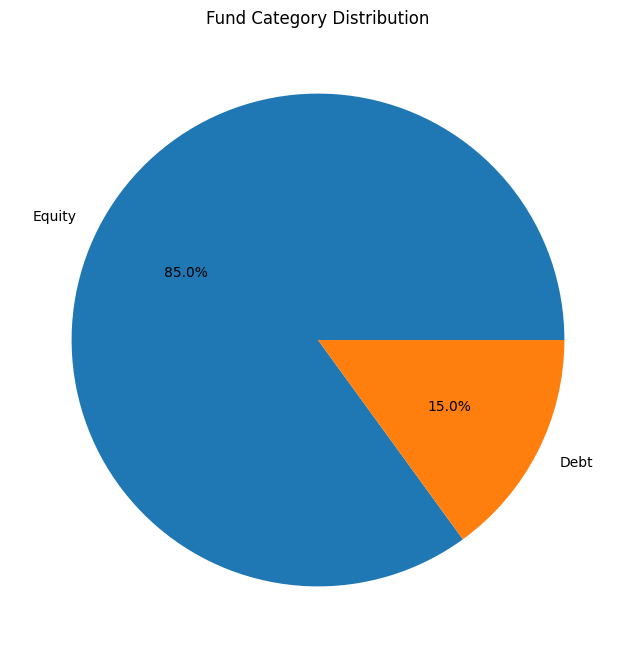

In [64]:
category_counts = fund_master["category"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%"
)

plt.title("Fund Category Distribution")

plt.savefig(
    "../reports/fund_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

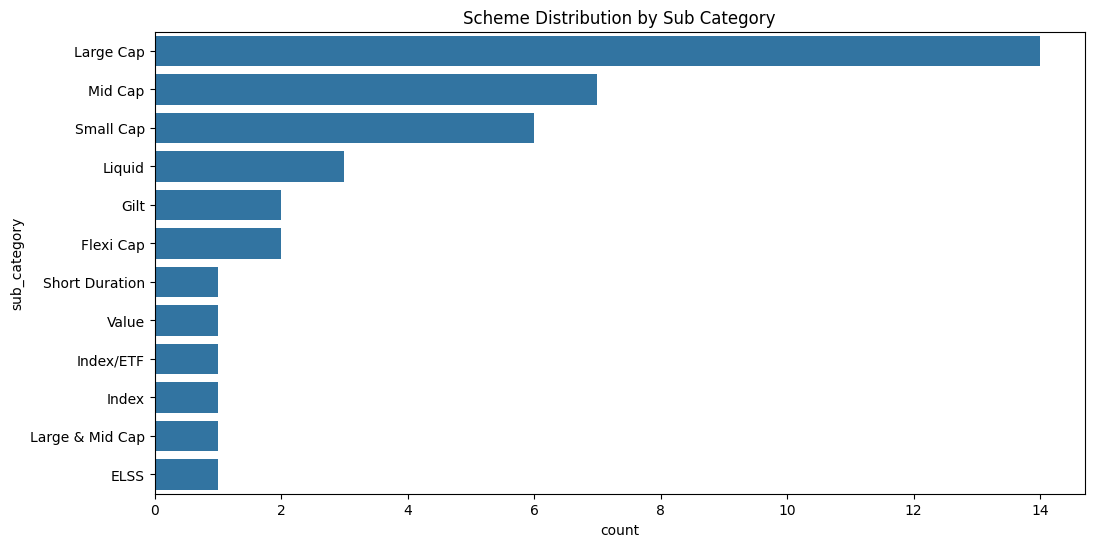

In [65]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=fund_master,
    y="sub_category",
    order=fund_master["sub_category"].value_counts().index
)

plt.title("Scheme Distribution by Sub Category")

plt.savefig(
    "../reports/subcategory_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

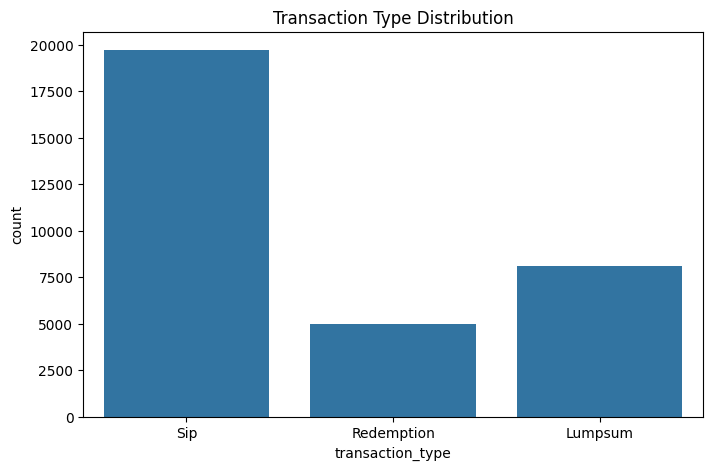

In [66]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="transaction_type"
)

plt.title("Transaction Type Distribution")

plt.savefig(
    "../reports/transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

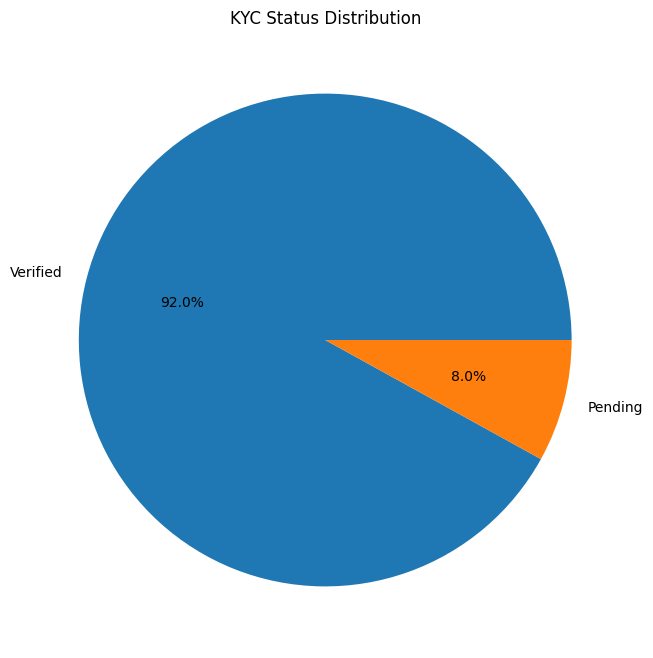

In [67]:
kyc_counts = transactions["kyc_status"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    kyc_counts,
    labels=kyc_counts.index,
    autopct="%1.1f%%"
)

plt.title("KYC Status Distribution")

plt.savefig(
    "../reports/kyc_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()